---

<h1 align="center"><b>ANÁLISIS EXPLORATORIO CUANTITATIVO - Estudio Crediticio</b></h1> 

---

<div style="text-align: justify; line-height: 1.5; font-size: 18px;"> 


Este notebook sirve como guía base para el curso de Analítica de Datos. Incluye procesos de carga de datos y análisis exploratorio (EDA) aplicados a un conjunto de datos que contiene información demográfica, laboral y financiera de individuos solicitantes de **crédito**. El objetivo principal es analizar el perfil socioeconómico de los clientes y predecir su comportamiento crediticio, el cual está representado por la variable objetivo (*Target*).

Cada registro corresponde a un individuo solicitante y contiene variables relacionadas con:

- Características demográficas

- Situación familiar

- Situación laboral

- Ingresos

- Canales de contacto

- Historial de cuenta

- La variable Target representa la variable objetivo del modelo.


</div>

---



# Librerías

In [1]:
# ================= #
# Cargar librearías #
# ================= #

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Carga de Datos

In [2]:
# =============== #
# Organizar rutas #
# =============== #

mainpath= "/Users/duvancatano/Documents/Data_Analytics_UdeA/ml-project/data/credit"
filename= "creditona_dataset.csv"
fullpath= os.path.join(mainpath,filename)

In [3]:
# ================ #
# Lectura de datos #
# ================ #

data = pd.read_csv(fullpath, sep=",")      # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

| **Variable** | **Significado** |
|----------|-------------|
| ID | Numero de identificacion unico para cada cliente. |
| Genero | Genero del solicitante (0: Femenino, 1: Masculino). |
| Posee_auto | Indica si el cliente tiene vehiculo propio (1: Si, 0: No). |
| Posee_propiedad | Indica si el cliente es dueño de vivienda o inmuebles (1: Si, 0: No). |
| Telefono_trabajo | Indica si el cliente registro un telefono de su lugar de empleo. |
| Telefono | Indica si el cliente registro un numero de telefono personal. |
| Correo_electronico | Indica si el cliente registro una direccion de e-mail. |
| Desempleado | Indica si el cliente esta sin empleo actualmente (Contiene valores nulos). |
| Num_hijos | Cantidad de hijos que tiene el solicitante. |
| Num_familiares | Numero total de personas en el grupo familiar (Contiene valores nulos). |
| Antiguedad_cuenta | Tiempo en meses desde la apertura de la cuenta de credito. |
| Ingresos_totales | Suma total de ingresos anuales del cliente. |
| Edad | Edad del cliente en años. |
| Anios_empleado | Tiempo que lleva el cliente en su empleo actual (Contiene valores nulos). |
| Tipo_ingresos | Categoria de la fuente economica (Ej: Trabajando, Pensionado). |
| Nivel_educativo | Grado maximo de estudios alcanzado. |
| Estado_civil | Condicion sentimental/legal (Ej: Casado, Soltero). |
| Tipo_vivienda | Situacion habitacional (Ej: Casa propia, Rentado). |
| Tipo_ocupacion | Labor especifica que desempeña el cliente. |
| Objetivo | Variable de riesgo (1: Mal pagador/Riesgo, 0: Buen pagador/Sin riesgo). |

---

# **Definición del Problema**

<div style="text-align: justify; line-height: 1.5; font-size: 18px;"> 

Se plantea un problema de clasificación en el ámbito del riesgo crediticio, cuyo propósito es identificar, a partir de la información disponible de los clientes, aquellos que presentan mayor probabilidad de incumplir sus obligaciones financieras. Para ello, se dispone de un conjunto de variables que describen características personales, económicas y sociales, como la edad, los ingresos, la situación laboral, el nivel educativo, la composición del grupo familiar y las condiciones de vivienda. A partir de estas variables, se busca establecer patrones de comportamiento que permitan diferenciar entre clientes con perfil de buen pagador y aquellos con mayor riesgo. Este tipo de análisis resulta fundamental para las entidades financieras, ya que facilita la toma de decisiones relacionadas con la aprobación de créditos, la gestión del riesgo y la definición de estrategias orientadas a minimizar posibles pérdidas derivadas del incumplimiento. Esto puede ayudar a responder preguntas como:

</div>


<div style="text-align: justify; line-height: 1.5; font-size: 18px;">

1. ¿Qué tan desbalanceada está la variable objetivo?
    - ¿Cuál es la proporción de clientes riesgosos vs no riesgosos?
    - ¿Qué baseline trivial tendría el modelo?

2. ¿Existe diferencia en el riesgo según el género?
    - ¿Hay sesgos o diferencias significativas?

3. ¿Cómo se relacionan los ingresos con el riesgo?
    - ¿Los clientes con menores ingresos tienen mayor probabilidad de incumplimiento?
    - ¿Hay outliers relevantes?

4. ¿La edad influye en el comportamiento de pago?
    - ¿Clientes jóvenes vs mayores presentan distintos niveles de riesgo?
    - ¿Relación lineal o no lineal?

5. ¿La estabilidad laboral reduce el riesgo?
    - ¿Clientes con empleo estable son mejores pagadores?

6. ¿Poseer vivienda o vehículo impacta el riesgo?
    - ¿Funcionan como proxies de estabilidad económica?

7. ¿El tamaño del grupo familiar influye?
    - ¿Mayor carga familiar implica mayor riesgo?

8. ¿El tipo de ingresos afecta el riesgo?
    - ¿Quiénes son más riesgosos?

9. ¿El nivel educativo está asociado al riesgo?
    - ¿Mayor educación implica menor riesgo?
    - ¿Hay categorías con comportamiento atípico?

10. ¿Las variables de contacto aportan información?
    - ¿Clientes más “rastreables” son menos riesgosos?

</div>

---

## **Objetivo General**

<div style="text-align: justify; line-height: 1.5; font-size: 18px;"> 
Analizar de manera exploratoria (EDA) las variables del dataset para identificar patrones, relaciones y posibles factores asociados al riesgo crediticio, considerando el desbalance de clases, con el fin de apoyar la construcción de modelos predictivos robustos e interpretables.

</div>

<div style="text-align: justify; line-height: 1.5; font-size: 18px;">   </div>

In [ ]:
# ======================= #
# Dimensiones del Dataset #
# ======================= #

data.shape

In [ ]:
# =========================================== #
# Mostrar las primeras 10 filas del DataFrame #
# =========================================== #

data.head(10) 

In [ ]:
# ========================================== #
# Mostrar las últimas 10 filas del DataFrame #
# ========================================== #

data.tail(10)

In [ ]:
# ================== #
# Campos en columnas #
# ================== #

data.columns.to_list()

In [ ]:
# ============================ #
# Información de las variables #
# ============================ #

data.info()

## **Funciones Pesonalizadas - Valores Perdidos y Nulos**

In [7]:
# Porcentaje de valores perdidos por variable #
def resum_missing(df):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum() *100/df.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Porcentaje'])
    return missing_data

# Resumen de posición de valores perdidos #
def posmissing(df):
    lista_miss = np.where(df.isna())
    v1 = pd.Series(np.ndarray.tolist(lista_miss[0]))
    v2 = pd.Series(np.ndarray.tolist(lista_miss[1]))
    resumen_vna = pd.concat([v1, v2], axis=1, keys=['posicion_fila', 'posicion_columna'])
    return resumen_vna

# Construcción función que cuenta ceros #
def count_zeros(df):
    total = (df == 0).astype(int).sum(axis=0)
    percent = ((df == 0).astype(int).sum(axis=0) *100/df.count())
    missing_data = pd.concat([total, percent], axis=1, keys=['Total_ceros', 'Porcentaje'])
    return missing_data.sort_values(by='Porcentaje', ascending=False)

In [ ]:
# =========================================== #
# Porcentaje de valores perdidos por variable #
# =========================================== #

resum_missing(data)

In [ ]:
# ======================== #
# Función que cuenta ceros #
# ======================== #

count_zeros(data)

In [ ]:
# ============================================= #
# Distribuciones de algunas variables numéricas #
# ============================================= #

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
figsize = (12, 8)

## EDA VISUAL: Distribuciones univariadas
fig, axes = plt.subplots(2, 2, figsize=(18, 15))
axes = axes.ravel()

# Variables clave numéricas
vars_num = ['Num_familiares',   
            'Ingresos_totales',
            'Edad',
            'Anios_empleado']
for i, var in enumerate(vars_num):
    axes[i].hist(data[var], bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
#plt.savefig('eda_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================== #  
# Matriz de correlación entre variables numéricas #
# =============================================== #

plt.figure(figsize=(10, 8))
#corr = data.select_dtypes(include=[np.number]).corr()
corr = data[['Num_hijos',	
             'Antiguedad_cuenta',
             'Num_familiares',   
             'Ingresos_totales',
             'Edad',
             'Anios_empleado']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
#plt.savefig('eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================== #
# Distribuciones de algunas variables categóricas #
# =============================================== #

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

cat_vars = ['Tipo_ingresos',
            'Nivel_educativo',
            'Estado_civil',
            'Tipo_vivienda',
            'Tipo_ocupacion']
for i, var in enumerate(cat_vars):
    if i < 5:
        data[var].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {var}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('eda_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
data.head()

,ID,Genero,Posee_auto,Posee_propiedad,Telefono_trabajo,Telefono,Correo_electronico,Desempleado,Num_hijos,Num_familiares,Antiguedad_cuenta,Ingresos_totales,Edad,Anios_empleado,Tipo_ingresos,Nivel_educativo,Estado_civil,Tipo_vivienda,Tipo_ocupacion,Objetivo
0,5008804,1,1,1,1,0,0,0.0,0,2.0,15,427500.0,32.868574,12.435574,Trabajando,Educacion superior,Union civil,Departamento rentado,Otro,1
1,5008806,1,1,1,0,0,0,0.0,0,2.0,29,112500.0,58.793815,3.104787,Trabajando,Secundaria / tecnica,Casado,Casa / departamento,Personal de seguridad,0
2,5008808,0,0,1,0,1,1,0.0,0,1.0,4,270000.0,52.321403,8.353354,Asociado comercial,Secundaria / tecnica,Soltero / no casado,Casa / departamento,Personal de ventas,0
3,5008812,0,0,1,0,0,0,1.0,0,1.0,20,283500.0,61.504343,0.000000,Pensionado,Educacion superior,Separado,Casa / departamento,Otro,0
4,5008815,1,1,1,1,1,1,0.0,0,2.0,5,270000.0,46.193967,2.105450,Trabajando,Educacion superior,Casado,Casa / departamento,Contadores,0


## **Imputación**

In [10]:
# ======================================== #
# Librerías para Imputación y Escalamiento #
# ======================================== #

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Proceso de Imputación #

data_imp = data.copy()

id_col = ["ID"]
target_col = ["Objetivo"]

X = data_imp.drop(columns=id_col + target_col)

cat_vars = [
    "Genero", "Posee_auto", "Posee_propiedad",
    "Telefono_trabajo", "Telefono", "Correo_electronico",
    "Tipo_ingresos", "Nivel_educativo",
    "Estado_civil", "Tipo_vivienda", "Tipo_ocupacion"
]

X_encoded = pd.get_dummies(X, columns=cat_vars, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

imputer = KNNImputer(n_neighbors=5, weights="distance")
X_imputed = imputer.fit_transform(X_scaled)

X_imputed = pd.DataFrame(
    scaler.inverse_transform(X_imputed),
    columns=X_encoded.columns,
    index=X.index
)

for col in X.columns:
    if col in X_imputed.columns:
        data_imp[col] = X_imputed[col]

data_imp["Desempleado"] = data_imp["Desempleado"].round().clip(0,1)
data_imp["Num_familiares"] = data_imp["Num_familiares"].round().clip(lower=0)
data_imp["Anios_empleado"] = data_imp["Anios_empleado"].clip(lower=0)
data_imp["Desempleado"] = data_imp["Desempleado"].astype(float)
data_imp["Num_familiares"] = data_imp["Num_familiares"].astype(int)

In [ ]:
# =========================== #
# Verificación de Completitud #
# =========================== #

resum_missing(data_imp)

,Total,Porcentaje
ID,0,0.0
Genero,0,0.0
Tipo_ocupacion,0,0.0
Tipo_vivienda,0,0.0
Estado_civil,0,0.0
Nivel_educativo,0,0.0
Tipo_ingresos,0,0.0
Anios_empleado,0,0.0
Edad,0,0.0
Ingresos_totales,0,0.0


In [11]:
data_imp.sample(20)

,ID,Genero,Posee_auto,Posee_propiedad,Telefono_trabajo,Telefono,Correo_electronico,Desempleado,Num_hijos,Num_familiares,Antiguedad_cuenta,Ingresos_totales,Edad,Anios_empleado,Tipo_ingresos,Nivel_educativo,Estado_civil,Tipo_vivienda,Tipo_ocupacion,Objetivo
7715,5116500,1,1,1,0,0,0,0.0,0.0,2,6.0,225000.0,24.687707,1.590724,Asociado comercial,Secundaria / tecnica,Casado,Casa / departamento,Personal de ventas,1
5700,5090740,0,0,1,0,0,0,1.0,0.0,2,3.0,45000.0,65.167663,0.000000,Pensionado,Secundaria / tecnica,Casado,Casa / departamento,Otro,0
3031,5046148,0,1,1,1,1,0,0.0,0.0,2,37.0,90000.0,52.797799,7.129510,Servidor publico,Secundaria / tecnica,Casado,Casa / departamento,Personal base,0
1573,5029175,1,0,0,0,0,0,0.0,0.0,1,17.0,202500.0,48.302155,9.103541,Trabajando,Secundaria / tecnica,Soltero / no casado,Departamento municipal,Obreros,0
4183,5065376,0,0,1,0,1,0,0.0,0.0,2,48.0,215550.0,28.553632,2.548991,Trabajando,Educacion superior,Casado,Casa / departamento,Personal tecnico calificado,1
9521,5149845,0,0,1,0,0,0,1.0,0.0,1,55.0,135000.0,59.858861,0.000000,Pensionado,Secundaria / tecnica,Viudo,Casa / departamento,Otro,1
4618,5068440,0,0,0,0,0,1,1.0,0.0,2,15.0,157500.0,57.621991,0.000000,Pensionado,Educacion superior,Casado,Casa / departamento,Otro,0
2376,5036888,0,0,1,0,0,0,1.0,0.0,2,46.0,112500.0,53.961409,0.000000,Pensionado,Secundaria / tecnica,Casado,Casa / departamento,Otro,0
6784,5100436,0,0,0,1,1,0,0.0,4.0,6,52.0,112500.0,35.633860,3.764622,Asociado comercial,Secundaria / tecnica,Casado,Casa / departamento,Otro,0
7446,5114183,1,0,0,1,0,0,0.0,0.0,1,8.0,135000.0,22.565830,2.193064,Trabajando,Secundaria / tecnica,Soltero / no casado,Casa / departamento,Obreros,0


In [ ]:
# Valores de Tipo de Ingresos #

data_imp["Tipo_ingresos"].unique().tolist()

['Trabajando',
 'Asociado comercial',
 'Pensionado',
 'Servidor publico',
 'Estudiante']

In [ ]:
# Valores de Nivel Educativo #

data_imp["Nivel_educativo"].unique().tolist()

['Educacion superior',
 'Secundaria / tecnica',
 'Superior incompleta',
 'Secundaria baja',
 'Grado academico']

In [ ]:
# Valores de Estado Civil #

data_imp["Estado_civil"].unique().tolist()

['Union civil', 'Casado', 'Soltero / no casado', 'Separado', 'Viudo']

In [ ]:
# Valores de Tipo Vivienda #

data_imp["Tipo_vivienda"].unique().tolist()

['Departamento rentado',
 'Casa / departamento',
 'Departamento municipal',
 'Con los padres',
 'Departamento cooperativo',
 'Departamento de oficina']

In [ ]:
#  Valores de Tipo Ocupacion #

data_imp["Tipo_ocupacion"].unique().tolist()

['Otro',
 'Personal de seguridad',
 'Personal de ventas',
 'Contadores',
 'Obreros',
 'Gerentes',
 'Conductores',
 'Personal base',
 'Personal tecnico calificado',
 'Personal de limpieza',
 'Personal de servicio privado',
 'Personal de cocina',
 'Obreros no calificados',
 'Personal medico',
 'Secretarios',
 'Meseros/barman',
 'Personal de RRHH',
 'Agentes inmobiliarios',
 'Personal de TI']

## **Gráficos de Barras**

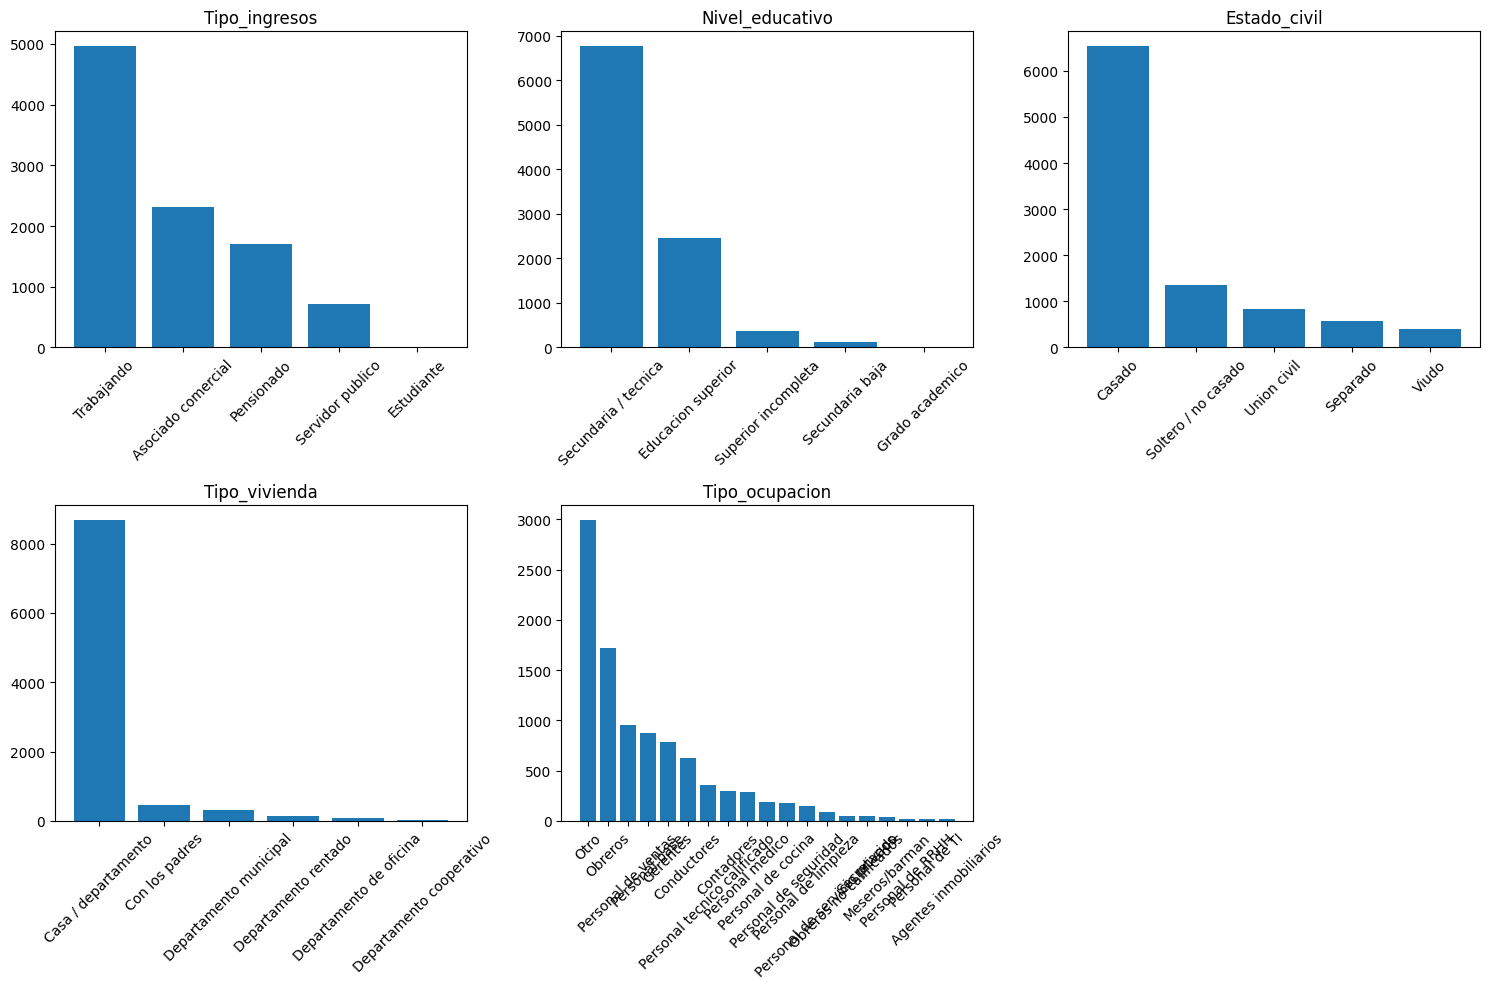

In [12]:
vars_cat = [
    "Tipo_ingresos", 
    "Nivel_educativo", 
    "Estado_civil", 
    "Tipo_vivienda", 
    "Tipo_ocupacion"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
    counts = data_imp[var].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

# Apagar la última gráfica (queda vacía)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

1. ¿Qué tan desbalanceada está la variable objetivo?
    - ¿Cuál es la proporción de clientes riesgosos vs no riesgosos?
    - ¿Qué baseline trivial tendría el modelo?

2. ¿Existe diferencia en el riesgo según el género?
    - ¿Hay sesgos o diferencias significativas?

3. ¿Cómo se relacionan los ingresos con el riesgo?
    - ¿Los clientes con menores ingresos tienen mayor probabilidad de incumplimiento?
    - ¿Hay outliers relevantes?

4. ¿La edad influye en el comportamiento de pago?
    - ¿Clientes jóvenes vs mayores presentan distintos niveles de riesgo?
    - ¿Relación lineal o no lineal?

5. ¿La estabilidad laboral reduce el riesgo?
    - ¿Clientes con empleo estable son mejores pagadores?

6. ¿Poseer vivienda o vehículo impacta el riesgo?
    - ¿Funcionan como proxies de estabilidad económica?

7. ¿El tamaño del grupo familiar influye?
    - ¿Mayor carga familiar implica mayor riesgo?

8. ¿El tipo de ingresos afecta el riesgo?
    - ¿Quiénes son más riesgosos?

9. ¿El nivel educativo está asociado al riesgo?
    - ¿Mayor educación implica menor riesgo?
    - ¿Hay categorías con comportamiento atípico?

10. ¿Las variables de contacto aportan información?
    - ¿Clientes más “rastreables” son menos riesgosos?

          Conteo  Proporcion  Porcentaje (%)
Objetivo                                    
0           8426    0.867855       86.785457
1           1283    0.132145       13.214543


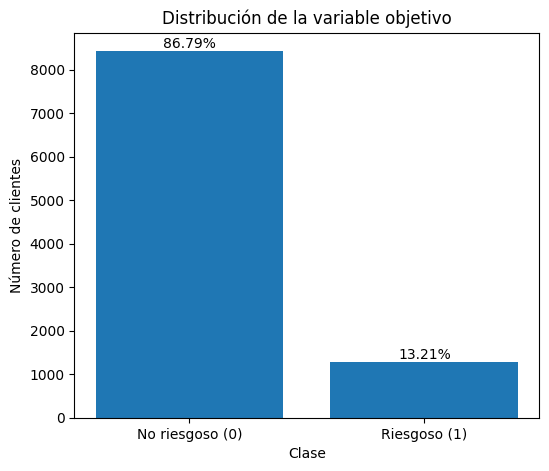

In [ ]:
# 1. ¿Qué tan desbalanceada está la variable objetivo? #


conteo = data_imp["Objetivo"].value_counts().sort_index()
proporcion = data_imp["Objetivo"].value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    "Conteo": conteo,
    "Proporcion": proporcion
})

balance["Porcentaje (%)"] = balance["Proporcion"] * 100

print(balance)


labels = ["No riesgoso (0)", "Riesgoso (1)"]

plt.figure(figsize=(6, 5))
plt.bar(labels, balance["Conteo"])

# Etiquetas con porcentaje
for i, v in enumerate(balance["Porcentaje (%)"]):
    plt.text(i, balance["Conteo"].iloc[i], f"{v:.2f}%", 
             ha='center', va='bottom')

plt.title("Distribución de la variable objetivo")
plt.ylabel("Número de clientes")
plt.xlabel("Clase")

plt.show()

        No riesgoso (0)  Riesgoso (1)
Genero                               
0              0.871580      0.128420
1              0.860898      0.139102


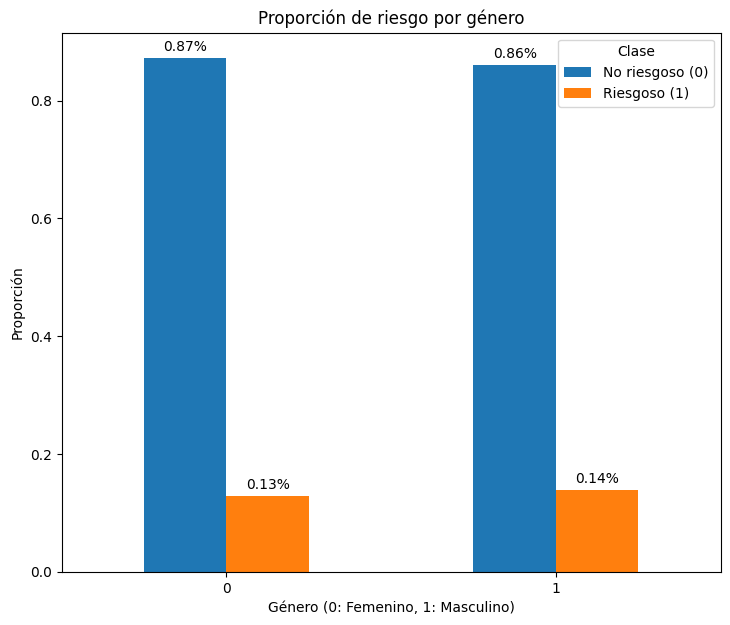

In [32]:
# =================================================== #
# 2. ¿Existe diferencia en el riesgo según el género? #
# =================================================== #

tabla = pd.crosstab(
    data_imp["Genero"], 
    data_imp["Objetivo"], 
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

print(tabla)

ax = tabla.plot(kind="bar", figsize=(8.5,7))

plt.title("Proporción de riesgo por género")
plt.xlabel("Género (0: Femenino, 1: Masculino)")
plt.ylabel("Proporción")
plt.xticks(rotation=0)

plt.legend(title="Clase")

# =========================
# Agregar porcentajes
# =========================

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", label_type="edge", padding=3)

plt.show()

          No riesgoso (0)  Riesgoso (1)
Edad_bin                               
20-30            0.844444      0.155556
30-40            0.858297      0.141703
40-50            0.872393      0.127607
50-60            0.877824      0.122176
60+              0.892262      0.107738


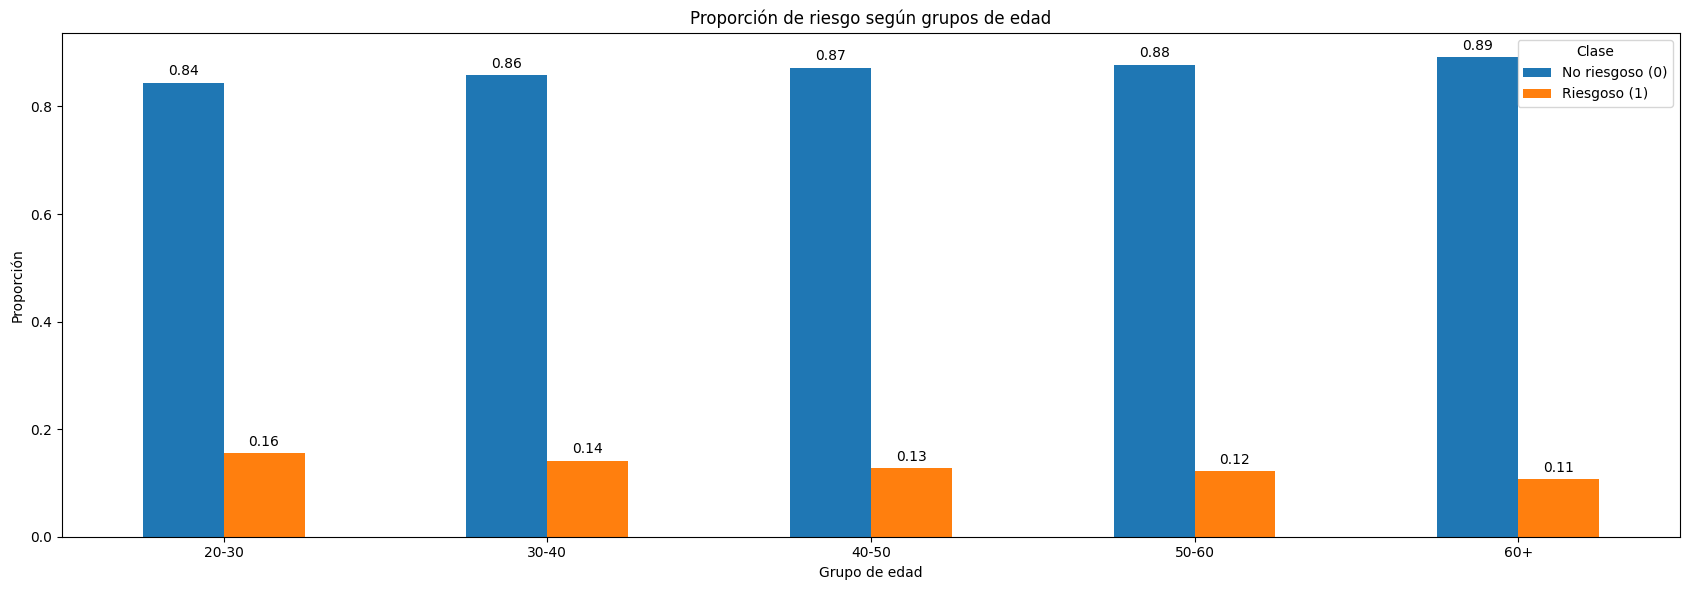

In [40]:
# 4. ¿La edad influye en el comportamiento de pago? 
# - ¿Clientes jóvenes vs mayores presentan distintos niveles de riesgo? 
# - ¿Relación lineal o no lineal?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Crear grupos de edad
# =========================

bins = [20, 30, 40, 50, 60, np.inf]
labels = ["20-30", "30-40", "40-50", "50-60", "60+"]

data_imp["Edad_bin"] = pd.cut(
    data_imp["Edad"],
    bins=bins,
    labels=labels,
    right=False  # intervalos tipo [20,30)
)

# =========================
# 2. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Edad_bin"], 
    data_imp["Objetivo"], 
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(17,6))

plt.title("Proporción de riesgo según grupos de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Proporción")
plt.xticks(rotation=0)

plt.legend(title="Clase")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()



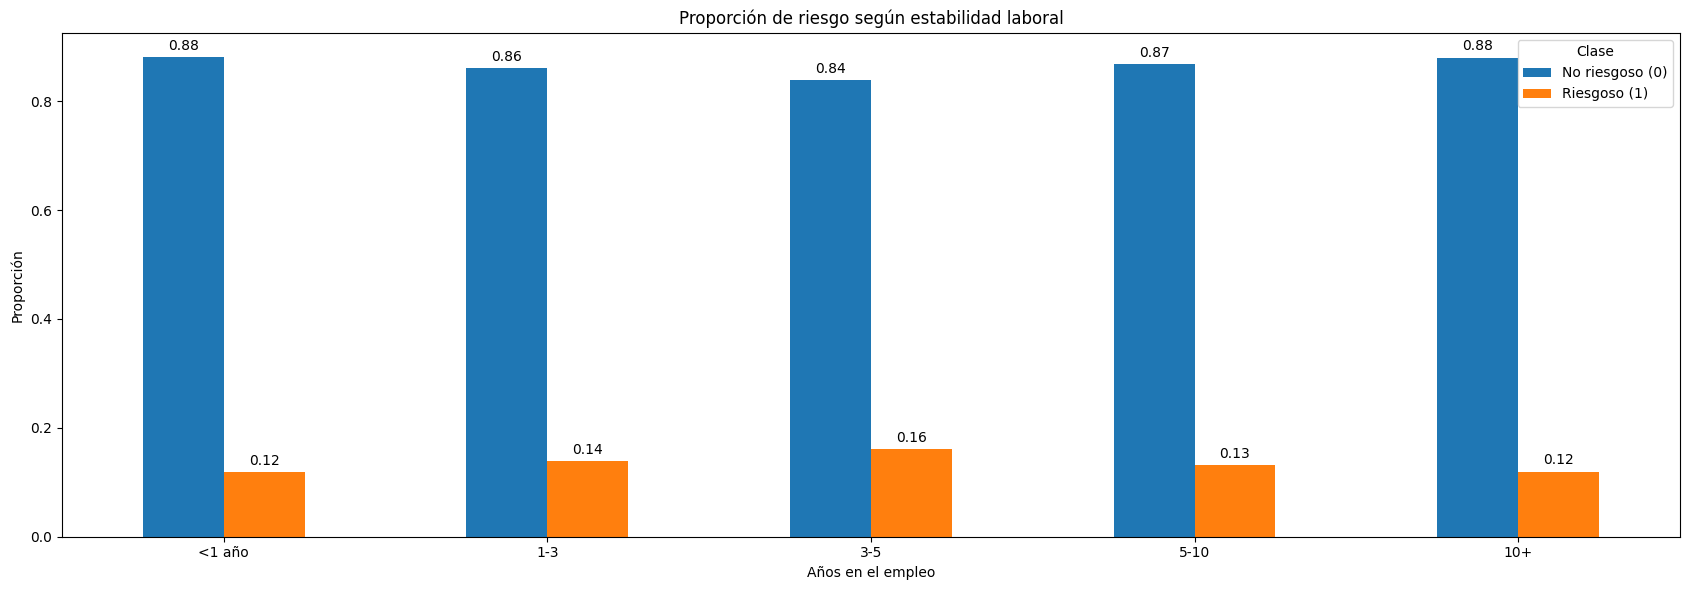

In [ ]:
#5. ¿La estabilidad laboral reduce el riesgo?
#    - ¿Clientes con empleo estable son mejores pagadores?


bins = [0, 1, 3, 5, 10, np.inf]
labels = ["<1 año", "1-3", "3-5", "5-10", "10+"]

data_imp["Estabilidad"] = pd.cut(
    data_imp["Anios_empleado"],
    bins=bins,
    labels=labels,
    right=False
)

tabla = pd.crosstab(
    data_imp["Estabilidad"], 
    data_imp["Objetivo"], 
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

ax = tabla.plot(kind="bar", figsize=(17,6))

plt.title("Proporción de riesgo según estabilidad laboral")
plt.xlabel("Años en el empleo")
plt.ylabel("Proporción")
plt.xticks(rotation=0)

plt.legend(title="Clase")

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()


                         No riesgoso (0)  Riesgoso (1)
Perfil_activos                                        
Con vivienda / Con auto         0.877053      0.122947
Con vivienda / Sin auto         0.873100      0.126900
Sin vivienda / Con auto         0.858577      0.141423
Sin vivienda / Sin auto         0.851555      0.148445


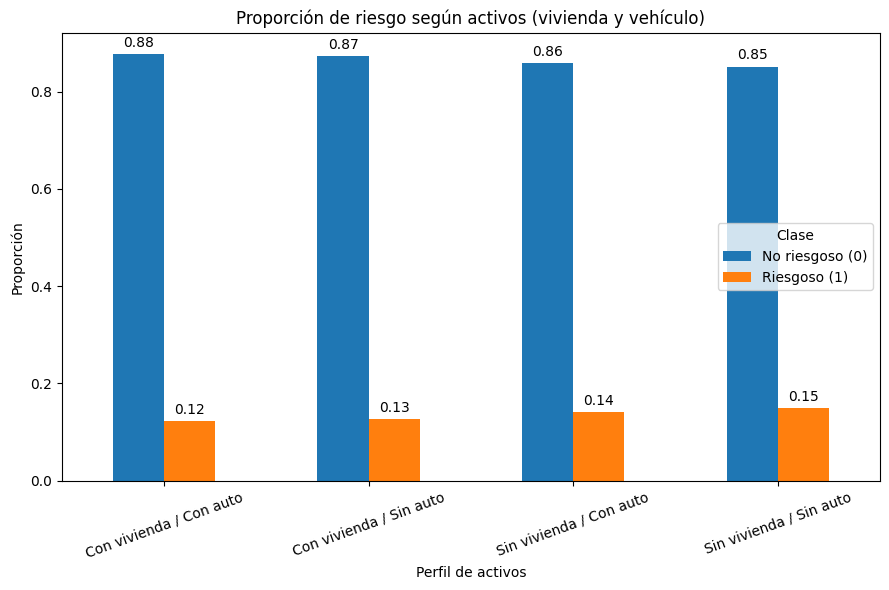

In [47]:
# 6. ¿Poseer vivienda o vehículo impacta el riesgo?
#    - ¿Funcionan como proxies de estabilidad económica?

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Crear variable combinada
# =========================

data_imp["Perfil_activos"] = (
    data_imp["Posee_propiedad"].astype(int).astype(str) + "_" +
    data_imp["Posee_auto"].astype(int).astype(str)
)

map_labels = {
    "0_0": "Sin vivienda / Sin auto",
    "0_1": "Sin vivienda / Con auto",
    "1_0": "Con vivienda / Sin auto",
    "1_1": "Con vivienda / Con auto"
}

data_imp["Perfil_activos"] = data_imp["Perfil_activos"].map(map_labels)

# =========================
# 2. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Perfil_activos"],
    data_imp["Objetivo"],
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(9,6))

plt.title("Proporción de riesgo según activos (vivienda y vehículo)")
plt.xlabel("Perfil de activos")
plt.ylabel("Proporción")
plt.xticks(rotation=20)

plt.legend(title="Clase")

# Etiquetas de porcentaje
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()


                No riesgoso (0)  Riesgoso (1)
Grupo_familiar                               
2-3                    0.869857      0.130143
4-5                    0.860379      0.139621
6+                     0.896296      0.103704


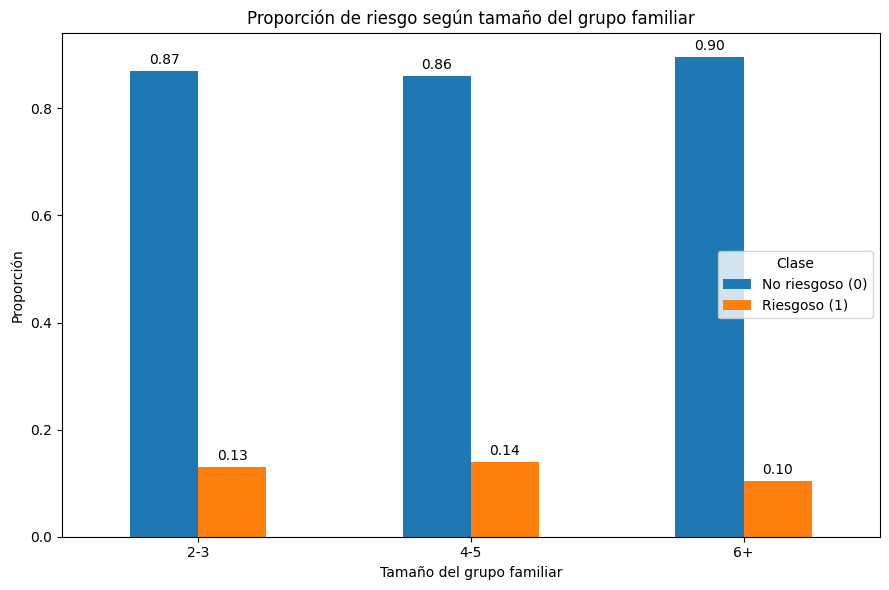

In [48]:
#7. ¿El tamaño del grupo familiar influye?
#    - ¿Mayor carga familiar implica mayor riesgo?


# =========================
# 1. Crear grupos de tamaño familiar
# =========================

bins = [0, 1, 3, 5, np.inf]
labels = ["1 persona", "2-3", "4-5", "6+"]

data_imp["Grupo_familiar"] = pd.cut(
    data_imp["Num_familiares"],
    bins=bins,
    labels=labels,
    right=False
)

# =========================
# 2. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Grupo_familiar"],
    data_imp["Objetivo"],
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(9,6))

plt.title("Proporción de riesgo según tamaño del grupo familiar")
plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Proporción")
plt.xticks(rotation=0)

plt.legend(title="Clase")

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

                    No riesgoso (0)  Riesgoso (1)
Tipo_ingresos                                    
Estudiante                 0.666667      0.333333
Asociado comercial         0.864187      0.135813
Trabajando                 0.865121      0.134879
Servidor publico           0.875346      0.124654
Pensionado                 0.877921      0.122079


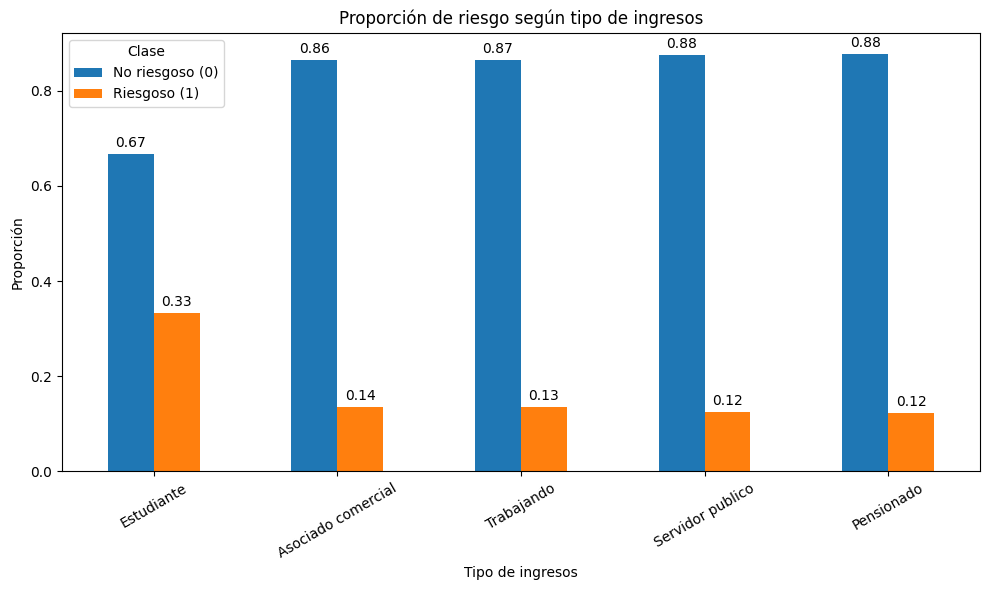

In [49]:
# 8. ¿El tipo de ingresos afecta el riesgo?
    #- ¿Quiénes son más riesgosos?
    
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Tipo_ingresos"],
    data_imp["Objetivo"],
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

# =========================
# 2. Ordenar por riesgo
# =========================

tabla = tabla.sort_values(by="Riesgoso (1)", ascending=False)

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(10,6))

plt.title("Proporción de riesgo según tipo de ingresos")
plt.xlabel("Tipo de ingresos")
plt.ylabel("Proporción")
plt.xticks(rotation=30)

plt.legend(title="Clase")

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

                      No riesgoso (0)  Riesgoso (1)
Nivel_educativo                                    
Grado academico              0.666667      0.333333
Superior incompleta          0.830189      0.169811
Educacion superior           0.864469      0.135531
Secundaria / tecnica         0.871173      0.128827
Secundaria baja              0.877193      0.122807


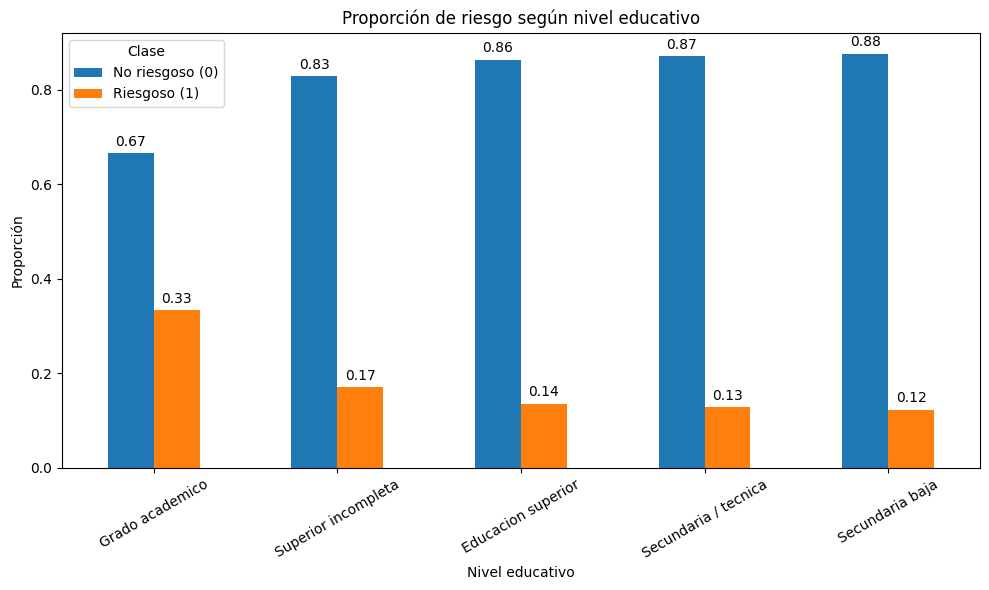

In [50]:
#9. ¿El nivel educativo está asociado al riesgo?
#    - ¿Mayor educación implica menor riesgo?
#    - ¿Hay categorías con comportamiento atípico?

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Nivel_educativo"],
    data_imp["Objetivo"],
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

# =========================
# 2. Ordenar por riesgo
# =========================

tabla = tabla.sort_values(by="Riesgoso (1)", ascending=False)

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(10,6))

plt.title("Proporción de riesgo según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Proporción")
plt.xticks(rotation=30)

plt.legend(title="Clase")

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()


                No riesgoso (0)  Riesgoso (1)
Contacto_score                               
0                      0.866543      0.133457
1                      0.869124      0.130876
2                      0.869702      0.130298
3                      0.879518      0.120482


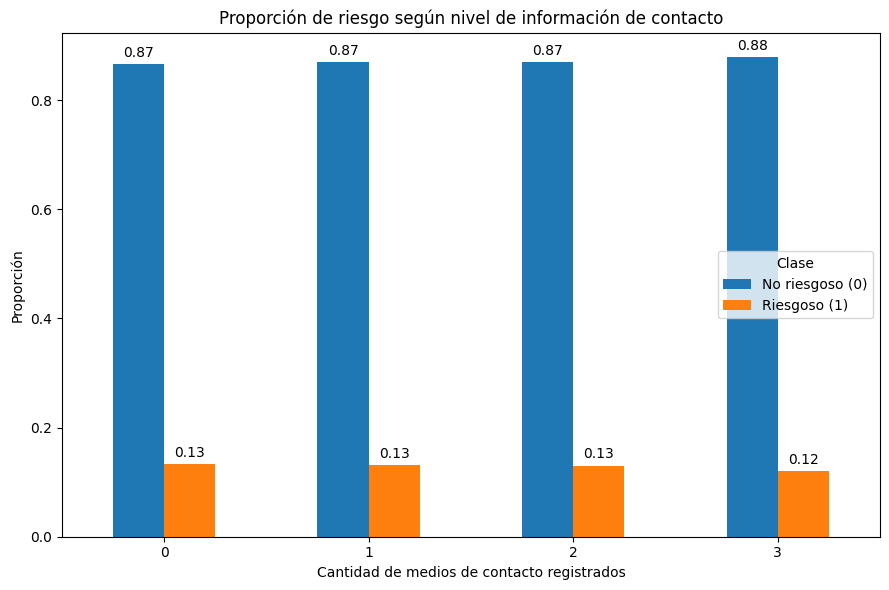

In [51]:
#10. ¿Las variables de contacto aportan información?
#    - ¿Clientes más “rastreables” son menos riesgosos?

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Crear score de contacto
# =========================

data_imp["Contacto_score"] = (
    data_imp["Telefono_trabajo"] +
    data_imp["Telefono"] +
    data_imp["Correo_electronico"]
)

# =========================
# 2. Tabla de proporciones
# =========================

tabla = pd.crosstab(
    data_imp["Contacto_score"],
    data_imp["Objetivo"],
    normalize="index"
)

tabla.columns = ["No riesgoso (0)", "Riesgoso (1)"]

# Ordenar por nivel de contacto
tabla = tabla.sort_index()

print(tabla)

# =========================
# 3. Gráfico
# =========================

ax = tabla.plot(kind="bar", figsize=(9,6))

plt.title("Proporción de riesgo según nivel de información de contacto")
plt.xlabel("Cantidad de medios de contacto registrados")
plt.ylabel("Proporción")
plt.xticks(rotation=0)

plt.legend(title="Clase")

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [52]:
data_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9709 entries, 0 to 9708
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ID                  9709 non-null   int64   
 1   Genero              9709 non-null   int64   
 2   Posee_auto          9709 non-null   int64   
 3   Posee_propiedad     9709 non-null   int64   
 4   Telefono_trabajo    9709 non-null   int64   
 5   Telefono            9709 non-null   int64   
 6   Correo_electronico  9709 non-null   int64   
 7   Desempleado         9709 non-null   float64 
 8   Num_hijos           9709 non-null   float64 
 9   Num_familiares      9709 non-null   int64   
 10  Antiguedad_cuenta   9709 non-null   float64 
 11  Ingresos_totales    9709 non-null   float64 
 12  Edad                9709 non-null   float64 
 13  Anios_empleado      9709 non-null   float64 
 14  Tipo_ingresos       9709 non-null   object  
 15  Nivel_educativo     9709 non-null   ob